# Imports

In [32]:
from pygsp import filters, graphs
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Problem 1

## Creating graph

In [33]:
G = graphs.Sensor(N = 100, seed = 1)

2026-04-22 22:19:12,064:[DEBUG](pygsp.graphs.nngraphs.nngraph.__init__): Using scipy KDTree for k-NN search


## Calculating fourier analysis

In [34]:
G.compute_fourier_basis()

In [35]:
G.U

array([[ 1.00000000e-01,  1.49545919e-01,  3.50570171e-02, ...,
         1.02491267e-03,  9.43121313e-05,  1.11622388e-02],
       [ 1.00000000e-01,  1.48379556e-01, -4.48058532e-02, ...,
        -4.57806271e-03, -6.41481308e-06, -2.54012736e-04],
       [ 1.00000000e-01, -3.86032525e-02, -1.21446563e-01, ...,
        -1.95205946e-03,  2.25385510e-04, -7.23546522e-04],
       ...,
       [ 1.00000000e-01, -2.40371296e-02, -1.54592941e-01, ...,
         1.00706374e-03, -8.86104019e-06,  2.43127544e-04],
       [ 1.00000000e-01, -3.32603836e-02, -1.18990155e-01, ...,
        -4.79732899e-03, -4.00782957e-04, -2.06648540e-03],
       [ 1.00000000e-01, -6.85985441e-02, -1.50321873e-01, ...,
         3.06284576e-05,  6.04296095e-05,  5.90155445e-06]],
      shape=(100, 100))

In [36]:
G.N

100

## Graph signals and GFT

In [37]:
rng = np.random.default_rng(2026)
random_signal = rng.standard_normal(G.N)

heat0 = filters.Heat(G, scale = 0)
heat10 = filters.Heat(G, scale = 10)

x1 = heat0.filter(random_signal)
x2 = heat10.filter(random_signal)

x1hat = G.gft(x1).squeeze()
x2hat = G.gft(x2).squeeze()

In [38]:

heat0 = filters.Heat(G, scale = 0)
heat10 = filters.Heat(G, scale = 10)

x1 = heat0.filter(random_signal)
x2 = heat10.filter(random_signal)

x1hat = G.gft(x1).squeeze()
x2hat = G.gft(x2).squeeze()

## Smoothness

In [39]:
S1 = x1.T @ G.L @ x1
print(f'The smoothness of the Heat filter with tau = 0 is {S1:.4f}')

S2 = x2.T @ G.L @ x2
print(f'The smoothness of the Heat filter with tau = 10 is {S2:.4f}')

The smoothness of the Heat filter with tau = 0 is 580.9577
The smoothness of the Heat filter with tau = 10 is 0.7838


## Plotting

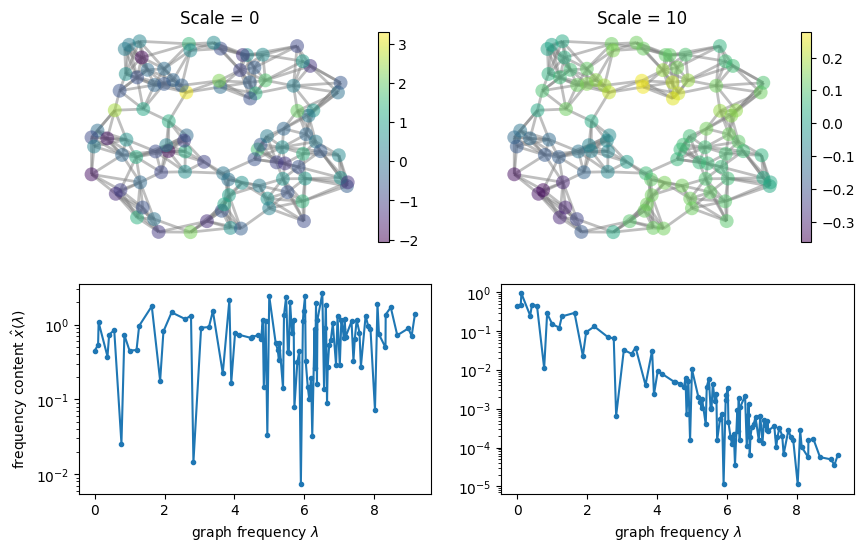

In [40]:
fig, axs = plt.subplots(2, 2 ,figsize = (10, 6))
G.plot(x1, ax = axs[0, 0])
axs[0, 0].set_axis_off()
axs[0, 0].set_title("Scale = 0")
axs[1, 0].plot(G.e, np.abs(x1hat), ".-")
axs[1, 0].set_xlabel(r"graph frequency $\lambda$")
axs[1, 0].set_ylabel(r"frequency content $\hat{x}(\lambda)$")
axs[1, 0].set_yscale('log')

G.plot(x2, ax = axs[0, 1])
axs[0, 1].set_axis_off()
axs[0, 1].set_title("Scale = 10")
axs[1, 1].plot(G.e, np.abs(x2hat), ".-")
axs[1, 1].set_xlabel(r"graph frequency $\lambda$")
axs[1, 1].set_yscale('log')
plt.show()

# Problem 2

## Generating graphs

In [41]:
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
from torch_geometric.utils import to_scipy_sparse_matrix

Retreiving data

In [42]:
dataset = Planetoid(root='./data/Cora', name='Cora')
Cora_data = dataset[0]

# Creating Cora Graph
W = to_scipy_sparse_matrix(Cora_data.edge_index, num_nodes=Cora_data.num_nodes)
W = (W + W.T) / 2          # symmetrize in case edges aren't already bidirectional
W.setdiag(0)  
Cora = graphs.Graph(W)

Generating graphs

In [43]:
N = 50
ER = graphs.ErdosRenyi(N = N, p = 0.1)
Ring = graphs.Ring(N = N)

c:\Users\djd14\miniconda3\envs\eel6878torch\Lib\site-packages\pygsp\graphs\graph.py:619: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = sparse.diags(self.dw)


## Plotting Graphs and Eigenvectors

### Erdos-Renyi Plot

In [44]:
ER.compute_fourier_basis()
ER.set_coordinates('spring')

c:\Users\djd14\miniconda3\envs\eel6878torch\Lib\site-packages\pygsp\graphs\graph.py:955: RuntimeWarning: invalid value encountered in divide
  m = W.dot(self.dw) / self.dw  # Mean degree of adjacent vertices.


### Ring Plot

In [45]:
Ring.compute_fourier_basis()

### Cora Graph Plot

In [46]:
Cora.set_coordinates(kind='spring')
Cora.compute_fourier_basis()

c:\Users\djd14\miniconda3\envs\eel6878torch\Lib\site-packages\pygsp\plotting.py:610: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  sc = ax.scatter(


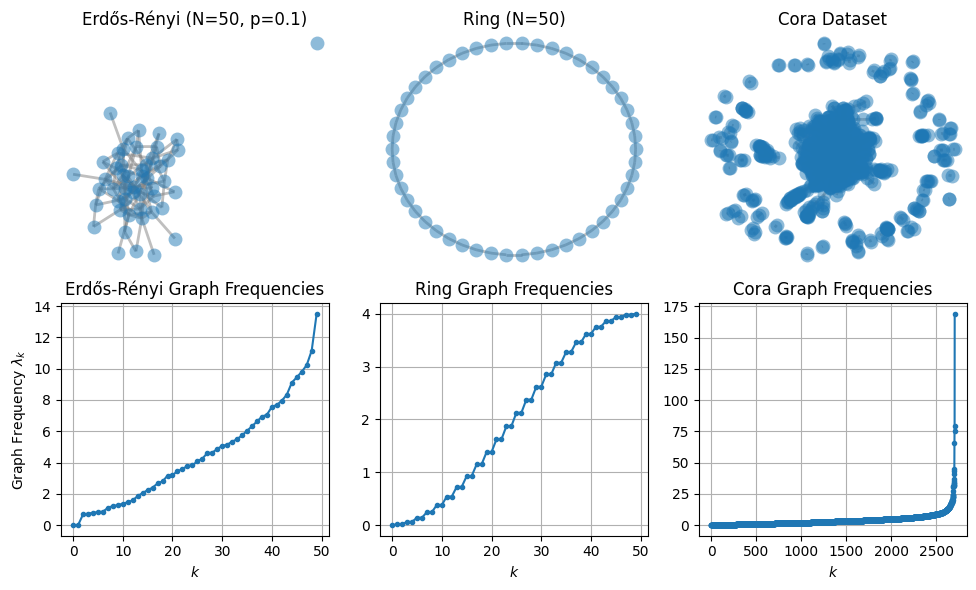

In [47]:
fig, axs = plt.subplots(2,3 ,figsize = (10, 6))
ER.plot(ax=axs[0, 0], title='Erdős-Rényi (N=50, p=0.1)')
axs[0, 0].set_axis_off()
axs[1, 0].plot(np.sort(ER.e), ".-")
axs[1, 0].set_title("Erdős-Rényi Graph Frequencies")
axs[1, 0].set_xlabel(r"$k$")
axs[1, 0].set_ylabel(r"Graph Frequency $\lambda_k$")
axs[1, 0].grid()


Ring.plot(ax=axs[0, 1], title='Ring (N=50)')
axs[0, 1].set_axis_off()
axs[1, 1].plot(np.sort(Ring.e), ".-")
axs[1, 1].set_title("Ring Graph Frequencies")
axs[1, 1].set_xlabel(r"$k$")
axs[1, 1].grid()

Cora.plot(ax=axs[0, 2], title='Cora Dataset')
axs[0, 2].set_axis_off()
axs[1, 2].plot(Cora.e, ".-")
axs[1, 2].set_title("Cora Graph Frequencies")
axs[1, 2].set_xlabel(r"$k$")
axs[1, 2].grid()

plt.tight_layout()
plt.show()

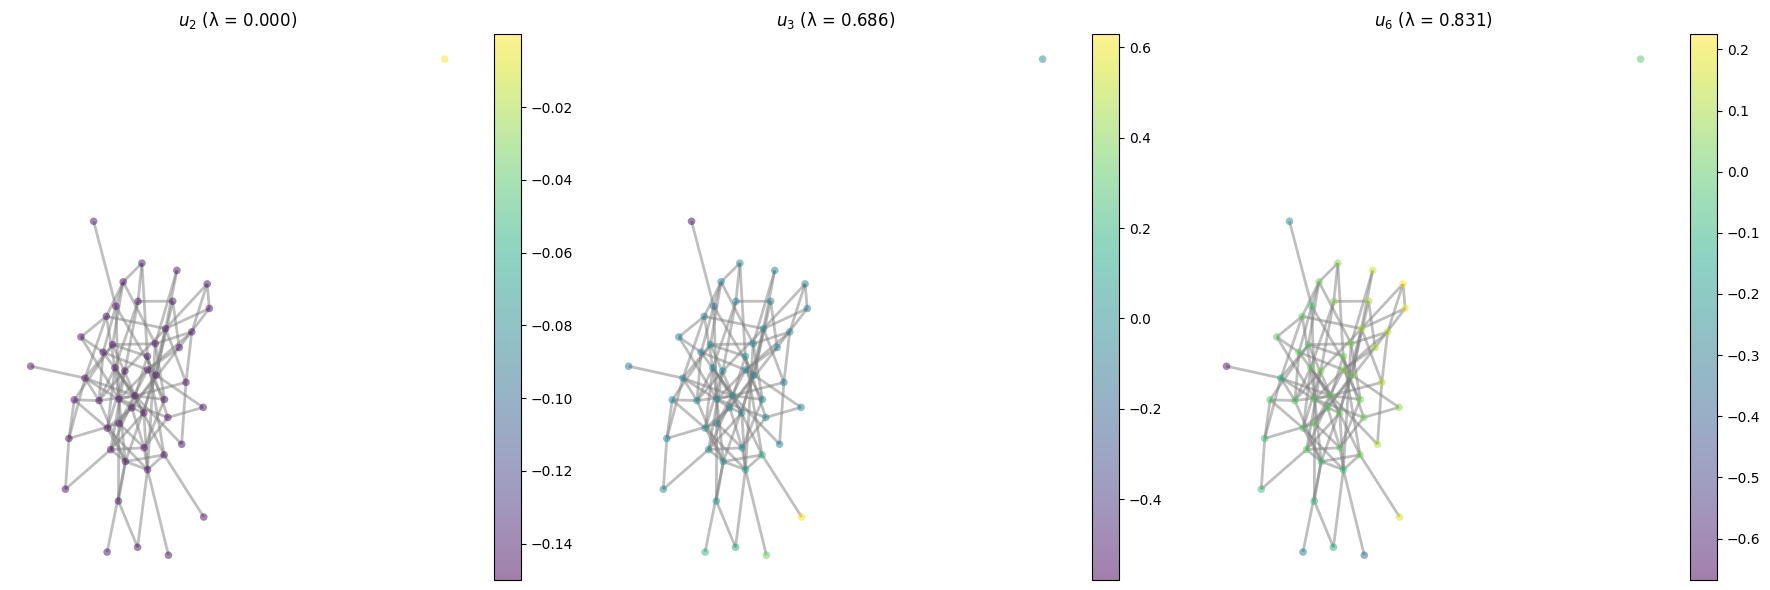

In [48]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for ax, k in zip(axs, [1, 2, 5]):  # u2, u3, u6
    ER.plot(ER.U[:, k], ax=ax, vertex_size=30)
    ax.set_title(f'$u_{{{k+1}}}$ (λ = {ER.e[k]:.3f})')
    ax.set_axis_off()

plt.tight_layout()
plt.show()

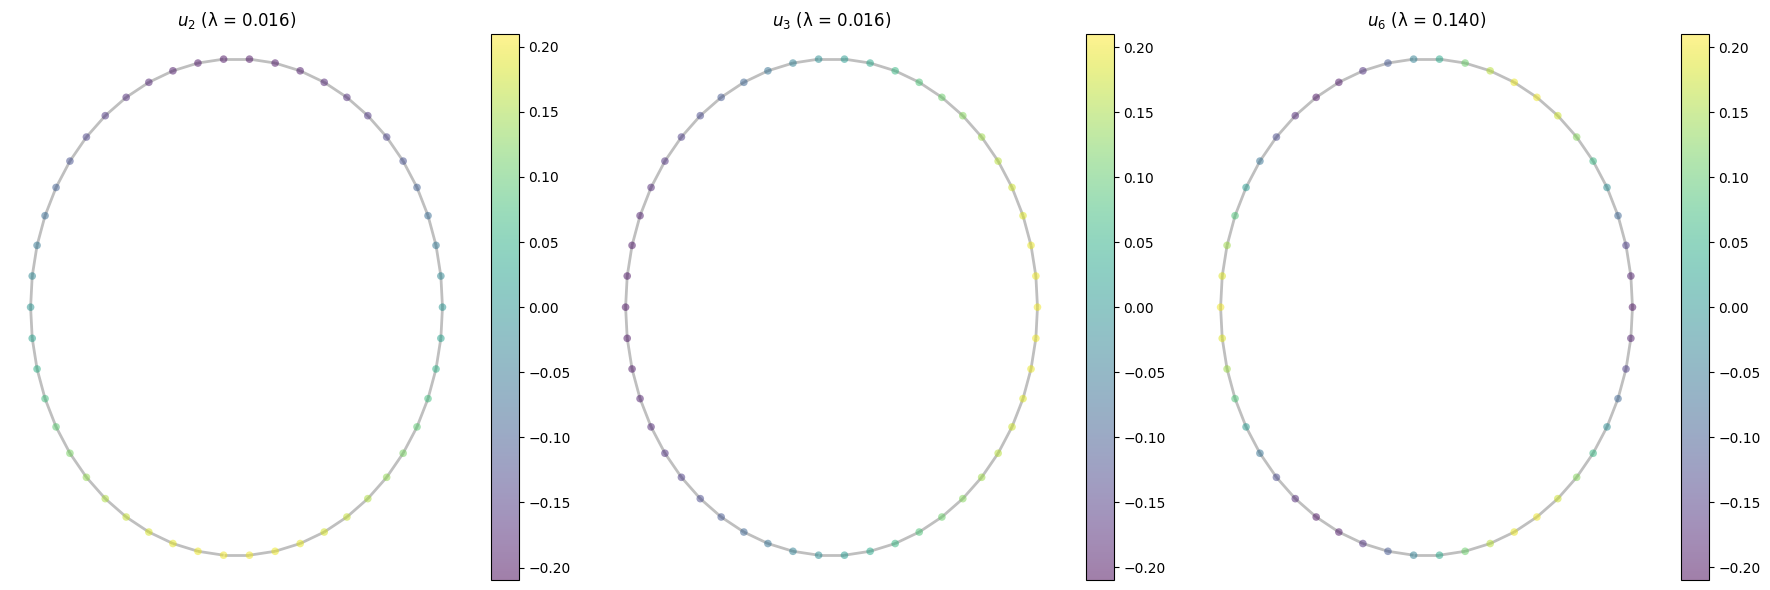

In [49]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for ax, k in zip(axs, [1, 2, 5]):  # u2, u3, u6
    Ring.plot(Ring.U[:, k], ax=ax, vertex_size=30)
    ax.set_title(f'$u_{{{k+1}}}$ (λ = {Ring.e[k]:.3f})')
    ax.set_axis_off()

plt.tight_layout()
plt.show()

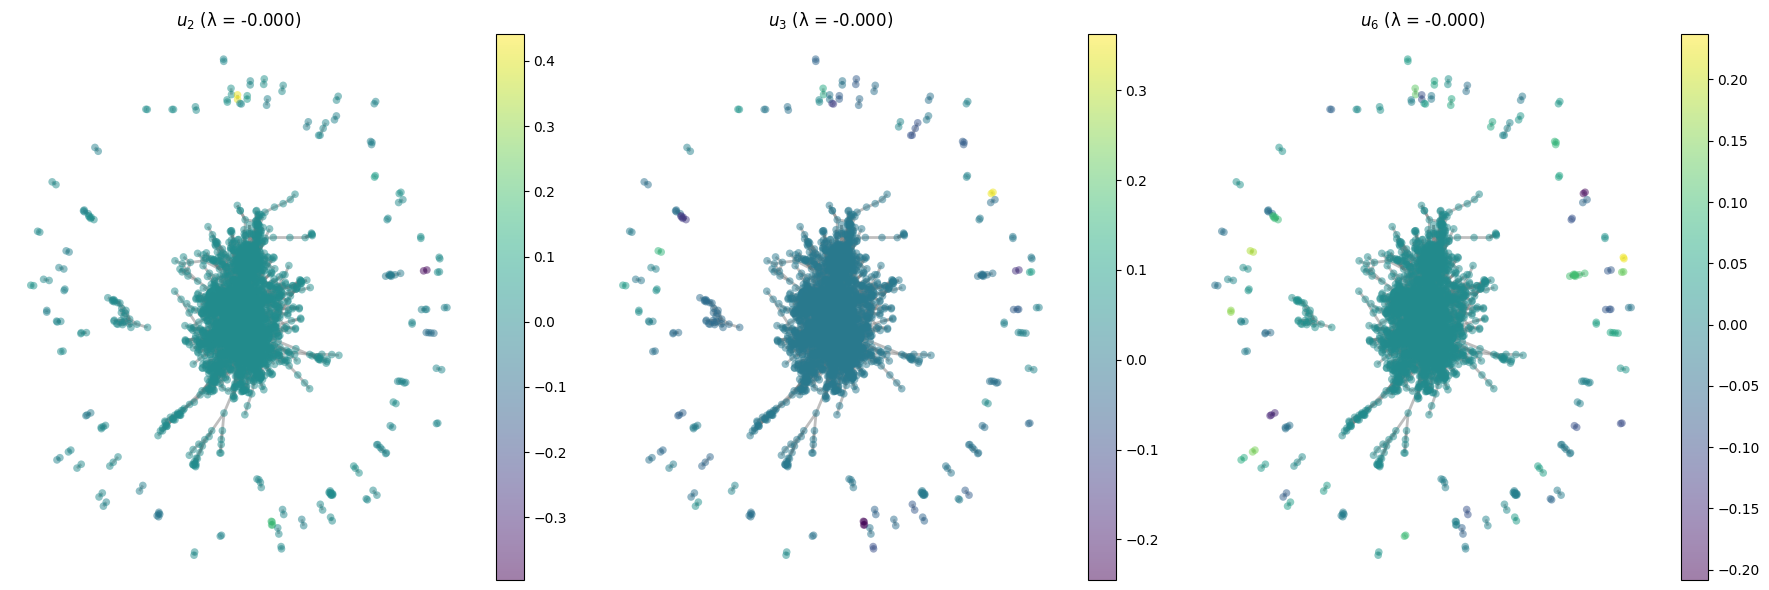

In [50]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for ax, k in zip(axs, [1, 2, 5]):  # u2, u3, u6
    Cora.plot(Cora.U[:, k], ax=ax, vertex_size=30)
    ax.set_title(f'$u_{{{k+1}}}$ (λ = {Cora.e[k]:.3f})')
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Part 3

In [51]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

Calculating Cora feature covariance matrix

In [52]:

CoraX = Cora_data.x.numpy()
CoraY = Cora_data.y.numpy()

cov = np.cov(CoraX.T)
cov

array([[ 5.87567983e-03, -7.20272787e-05,  2.16627497e-04, ...,
        -1.30958689e-05, -1.41871913e-04, -2.61917377e-05],
       [-7.20272787e-05,  1.20420607e-02, -3.15119344e-04, ...,
        -2.70102295e-05, -2.92610820e-04, -5.40204590e-05],
       [ 2.16627497e-04, -3.15119344e-04,  2.51904494e-02, ...,
        -5.72944262e-05,  1.18135650e-04, -1.14588852e-04],
       ...,
       [-1.30958689e-05, -2.70102295e-05, -5.72944262e-05, ...,
         2.21156485e-03,  3.16210667e-04, -9.82190164e-06],
       [-1.41871913e-04, -2.92610820e-04,  1.18135650e-04, ...,
         3.16210667e-04,  2.34354666e-02,  2.63008699e-04],
       [-2.61917377e-05, -5.40204590e-05, -1.14588852e-04, ...,
        -9.82190164e-06,  2.63008699e-04,  4.41330780e-03]],
      shape=(1433, 1433))

## Using t-SNE

In [53]:
tSNE = TSNE(n_components = 2, random_state=0).fit_transform(CoraX)
labels = KMeans(n_clusters = 7, n_init = 10, random_state=0).fit_predict(tSNE)

In [54]:
ARI = adjusted_rand_score(CoraY, labels)
ARI

0.10931505864003274

In [55]:
SIL = silhouette_score(tSNE, labels)
SIL

0.37837326526641846

## Part 4

### (a)

In [56]:
i = np.linspace(-np.pi, np.pi, N)
x = np.sin(i) + np.cos(2*i) + 0.5*np.cos(30*i)
x_noisy = x + rng.uniform(-0.4, 0.4, N)

### (b)

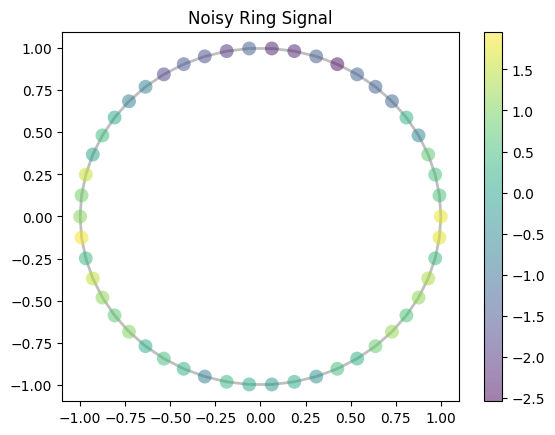

In [57]:
Ring.plot(x_noisy, title="Noisy Ring Signal")
plt.show()

### (c)

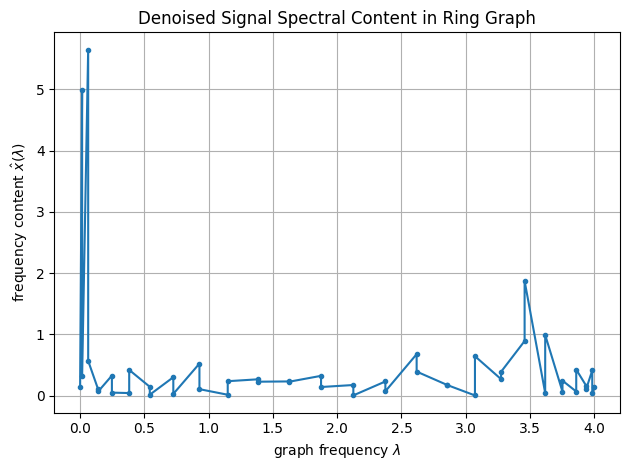

In [58]:
fig = plt.figure()
plt.plot(Ring.e, np.abs(Ring.gft(x_noisy)), ".-")

plt.xlabel(r"graph frequency $\lambda$")
plt.ylabel(r"frequency content $\hat{x}(\lambda)$")
plt.title('Denoised Signal Spectral Content in Ring Graph')
plt.grid()
plt.tight_layout()
plt.show()

### (d)

In [59]:
def h(l, alpha = 2):
    return 1 / (1 + alpha * l)
g = filters.Filter(Ring, h)

### (e)

In [60]:
x_denoised = g.filter(x_noisy, method = 'exact')

### (f)

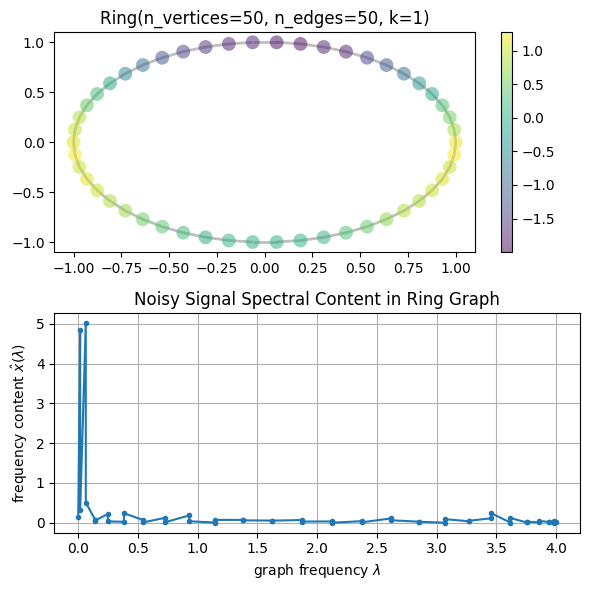

In [61]:
fig, axs = plt.subplots(2, 1 ,figsize = (6, 6))
Ring.plot(x_denoised, ax = axs[0])

axs[1].plot(Ring.e, np.abs(Ring.gft(x_denoised)), ".-")

axs[1].set_xlabel(r"graph frequency $\lambda$")

axs[1].set_ylabel(r"frequency content $\hat{x}(\lambda)$")
axs[1].set_title('Noisy Signal Spectral Content in Ring Graph')
axs[1].grid()
plt.tight_layout()
plt.show()
